In [ ]:
# Install AerEO and any required plugins for this notebook (Google Colab)
!pip install -q "aereo[viz]"

In [ ]:
# Download config files and AOIs from the GitHub repository so this
# notebook can run outside the repo (e.g. Google Colab).
import os
import urllib.request

GITHUB_RAW = "https://raw.githubusercontent.com/frandorr/aereo/main"

os.makedirs("config/aoi", exist_ok=True)

# Config files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_sentinel2.yaml",
    "config/job_sentinel2.yaml",
)
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_sentinel2-ndvi.yaml",
    "config/job_sentinel2-ndvi.yaml",
)
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_sentinel2-ndwi.yaml",
    "config/job_sentinel2-ndwi.yaml",
)

# AOI files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/aoi/chocon.geojson",
    "config/aoi/chocon.geojson",
)

## Config used in this notebook

This notebook loads the job from `examples/config/job_sentinel2-ndwi.yaml`. It extends `job_sentinel2-ndvi` and changes the bands and preprocess stage to compute `NDWI`:

```yaml
defaults:
  - job_sentinel2-ndvi
  - _self_

name: sentinel2_ndwi
target_bands: [green, nir]

preprocess:
  - _target_: aereo.builtins.ndwi
    _partial_: true
    ndwi_nir_band: nir
    ndwi_green_band: green

reproject:
  _target_: aereo.builtins.reproject_odc
  _partial_: true
reproject_mode: grid
resolution: 10
```


2026-07-08 14:49:17 [info     ] search_called                  provider=search_stac
2026-07-08 14:49:19 [info     ] build_tasks_start              assets=16 builder=build_grouped_tasks
Extracting...
2026-07-08 14:49:19 [info     ] execute_start                  executor=LocalExecutor task_count=8
✓ Extracted 56 artifacts
Plotting...


(<Figure size 2000x1495.93 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


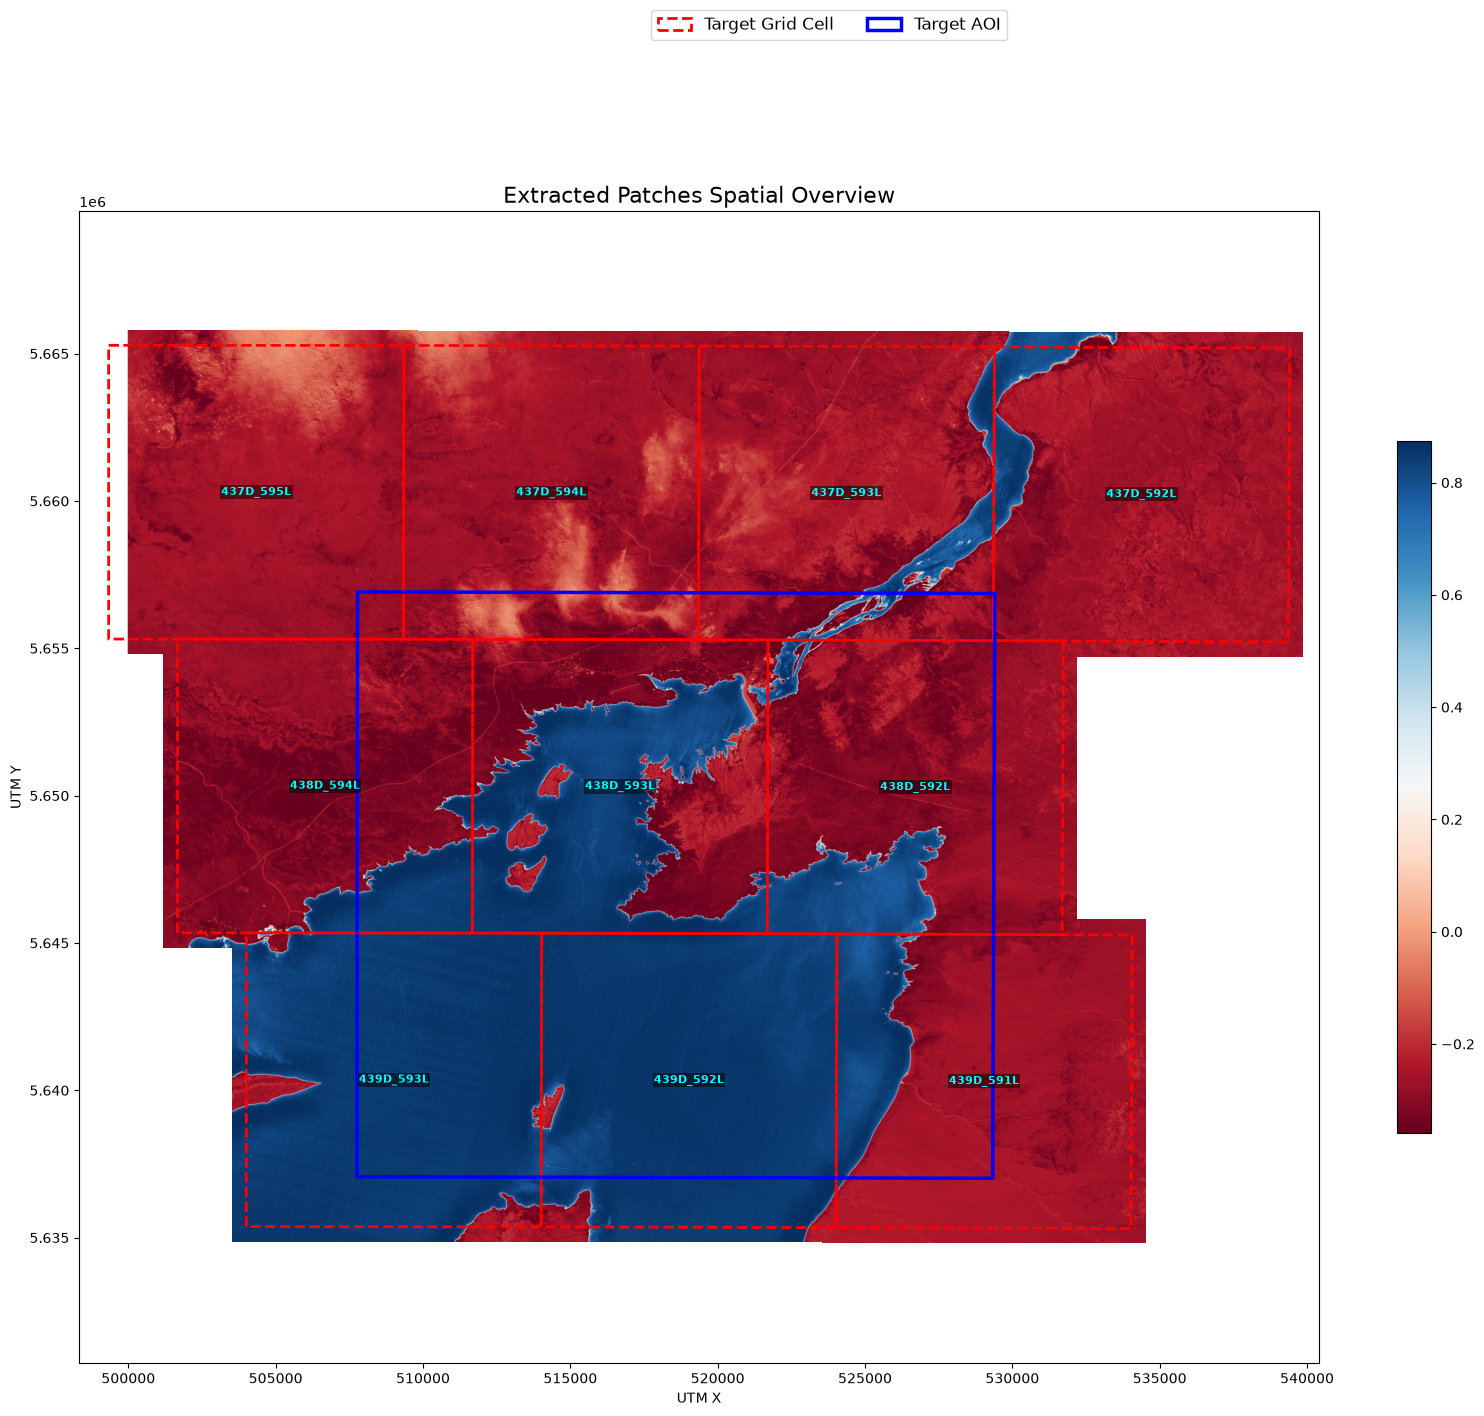

In [1]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob
from aereo.viz import plot_artifact_patches

# Load the job from the Hydra config package.
job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_sentinel2-ndwi",
)
assets = job.search()  # Use the search method from the job object to get the assets.
tasks = job.build_tasks(assets)

# now we create an Executor, in this case a LocalExecutor to run
# each ExtractionTask using Threads
local_exec = LocalExecutor(workers=-1, use_threads=True, cache=TaskResultCache())
# Extract!
print("Extracting...")
artifacts = job.execute(tasks, executor=local_exec)
print(f"✓ Extracted {len(artifacts.uri.unique())} artifacts")
print("Plotting...")

plot_artifact_patches(
    artifacts,
    ds_factor=1,
    cmap="RdBu",
    stretch="percentile",
    aoi=job.target_aoi,
    aoi_edgecolor="blue",
)